# 🔬 Quantum Superposition Demo

## Setup & imports

We use **Qiskit** with its built‑in `BasicSimulator`.

In [29]:
import matplotlib.pyplot as plt
import random
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.quantum_info import Statevector

## Build the circuit: apply H to |0⟩

A classical bit is always 0 **or** 1.  The Hadamard gate puts a qubit into an *equal superposition* of both:$$H\,|0\rangle \;=\; \frac{|0\rangle + |1\rangle}{\sqrt{2}}$$Think of it as a **perfectly fair quantum coin flip**.

In [44]:
qc = QuantumCircuit(1)
qc.h(0)
qc.draw()

┌───┐
q: ┤ H ├
   └───┘

## Exact quantum state (no noise)
Before we measure, we can peek at the **statevector** —  the complex amplitudes that define the qubit.

In [31]:
state = Statevector.from_instruction(qc)
amp_0, amp_1 = state.data
p_0, p_1 = state.probabilities()
print(f"Amplitude  |0⟩ : {amp_0: .5f}")
print(f"Amplitude  |1⟩ : {amp_1: .5f}")
print(f"Probability |0⟩: {p_0:.4f}")
print(f"Probability |1⟩: {p_1:.4f}")
print()
print("→ Both amplitudes are 1/√2 ≈ 0.707, so each outcome has probability (0.707)\u00B2 = 0.5.")

Amplitude  |0⟩ :  0.70711+0.00000j
Amplitude  |1⟩ :  0.70711+0.00000j
Probability |0⟩: 0.5000
Probability |1⟩: 0.5000

→ Both amplitudes are 1/√2 ≈ 0.707, so each outcome has probability (0.707)² = 0.5.


## Sample measurements (rapid simulator)
Now we add a measurement gate, run 2 000 shots, and look at the histogram.  We expect a roughly **50 / 50** split.

In [32]:
shots = 2000
backend = BasicSimulator()
seed = random.randint(0, 2 ** 32 - 1)
qc_m = QuantumCircuit(1, 1)  # 1 Qubit and 1 bit
qc_m.h(0)  # The first qubit
qc_m.measure(0, 0)  # First qubit and first bit
compiled = transpile(qc_m, backend, seed_transpiler=seed)
result   = backend.run(compiled, shots=shots, seed_simulator=seed).result()
counts   = result.get_counts()
count_0 = counts.get("0", 0)
count_1 = counts.get("1", 0)
print(f"Raw counts : {counts}")
print(f"P(0) empirical: {count_0/shots:.3f}")
print(f"P(1) empirical: {count_1/shots:.3f}")

Raw counts : {'1': 1011, '0': 989}
P(0) empirical: 0.494
P(1) empirical: 0.505


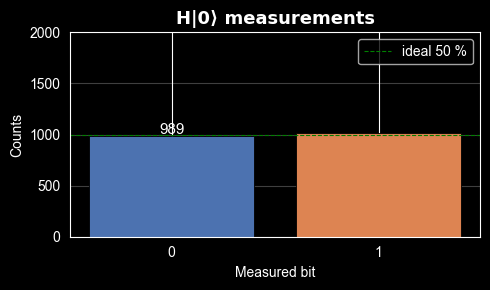

<Figure size 640x480 with 0 Axes>

In [33]:
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(["0", "1"], [count_0, count_1],              color=["#4C72B0", "#DD8452"], edgecolor="black", linewidth=0.6)
ax.set_title("H|0⟩ measurements", fontsize=13, fontweight="bold", fontfamily="DejaVu Sans")
ax.set_xlabel("Measured bit")
ax.set_ylabel("Counts")
ax.set_ylim(0, shots)
ax.axhline(shots / 2, color="green", linestyle="--", linewidth=0.8, label="ideal 50 %")
ax.legend()
ax.grid(axis="y", alpha=0.25)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,            str(int(bar.get_height())), ha="center", fontsize=11)
    plt.tight_layout()
    plt.show()

## Validation

In [34]:
assert abs(p_0 - 0.5) < 1e-9, f"Exact P(0) should be 0.5, got {p_0}"
assert abs(p_1 - 0.5) < 1e-9, f"Exact P(1) should be 0.5, got {p_1}"
assert abs(count_0/shots - 0.5) < 0.08, f"Empirical P(0) too far from 0.5"
assert abs(count_1/shots - 0.5) < 0.08, f"Empirical P(1) too far from 0.5"
print("✅  Single H: equal superposition confirmed (exact & empirical).")

✅  Single H: equal superposition confirmed (exact & empirical).


## H applied twice (H² = I)
The Hadamard gate is its a Hermitian Matrix, so it's its own inverse.  Applying it **twice** returns the qubit to its original state:$$H\bigl(H\,|0\rangle\bigr) = H^2\,|0\rangle = I\,|0\rangle = |0\rangle$$So measurement should yield `0` with probability **≈ 1**.

In [52]:
qc_hh = QuantumCircuit(1)
qc_hh.h(0)
qc_hh.h(0)
state_hh = Statevector.from_instruction(qc_hh)
p0_hh, p1_hh = state_hh.probabilities()
print(f"\nExact state →  P(0)={p0_hh:.3f}   P(1)={p1_hh:.3f}")
qc_hh.draw(output="text")


Exact state →  P(0)=1.000   P(1)=0.000


┌───┐┌───┐
q: ┤ H ├┤ H ├
   └───┘└───┘

In [36]:
qc_hh_m = QuantumCircuit(1, 1)
qc_hh_m.h(0)
qc_hh_m.h(0)
qc_hh_m.measure(0, 0)
compiled_hh = transpile(qc_hh_m, backend, seed_transpiler=seed)
result_hh   = backend.run(compiled_hh, shots=shots, seed_simulator=seed).result()
counts_hh   = result_hh.get_counts()
count_0_hh = counts_hh.get("0", 0)
count_1_hh = counts_hh.get("1", 0)
print(f"Raw counts : {counts_hh}")
print(f"P(0) empirical: {count_0_hh/shots:.3f}")
print(f"P(1) empirical: {count_1_hh/shots:.3f}")

Raw counts : {'0': 2000}
P(0) empirical: 1.000
P(1) empirical: 0.000


## Takeaways
| Experiment | Exact P(0) | Exact P(1) | Empirical split |
|------------|:----------:|:----------:|:---------------:|
| H \|0⟩     |   0.500    |   0.500    | ≈ 50 / 50       |
| H(H \|0⟩)  |   1.000    |   0.000    | ≈ 100 / 0       |

**Key insight:**  `H` does **not** produce randomness on its own — it creates *superposition*.
Randomness only appears when a **measurement** collapses the state.
Applying `H` twice cancels the superposition entirely, proving the gate is *reversible*.
